In [42]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from scipy.ndimage import convolve


image = img_as_float(data.camera())

In [43]:
kirsch_masks = [
    ("North", np.array([[ 5,  5,  5],
                        [-3,  0, -3],
                        [-3, -3, -3]])),

    ("North-East", np.array([[ 5,  5, -3],
                             [ 5,  0, -3],
                             [-3, -3, -3]])),

    ("East", np.array([[ 5, -3, -3],
                       [ 5,  0, -3],
                       [ 5, -3, -3]])),

    ("South-East", np.array([[-3, -3, -3],
                              [ 5,  0, -3],
                              [ 5,  5, -3]])),

    ("South", np.array([[-3, -3, -3],
                        [-3,  0, -3],
                        [ 5,  5,  5]])),

    ("South-West", np.array([[-3, -3, -3],
                             [-3,  0,  5],
                             [-3,  5,  5]])),

    ("West", np.array([[-3, -3,  5],
                       [-3,  0,  5],
                       [-3, -3,  5]])),

    ("North-West", np.array([[-3,  5,  5],
                             [-3,  0,  5],
                             [-3, -3, -3]])),
]


In [44]:
responses = []
for name, kernel in kirsch_masks:
    response = convolve(image, kernel)
    responses.append((name, response))



The code below select the maximum convolution value from the 8 kernel's result

In [45]:
#max response
kirsch_final = np.max([r for _, r in responses], axis=0)

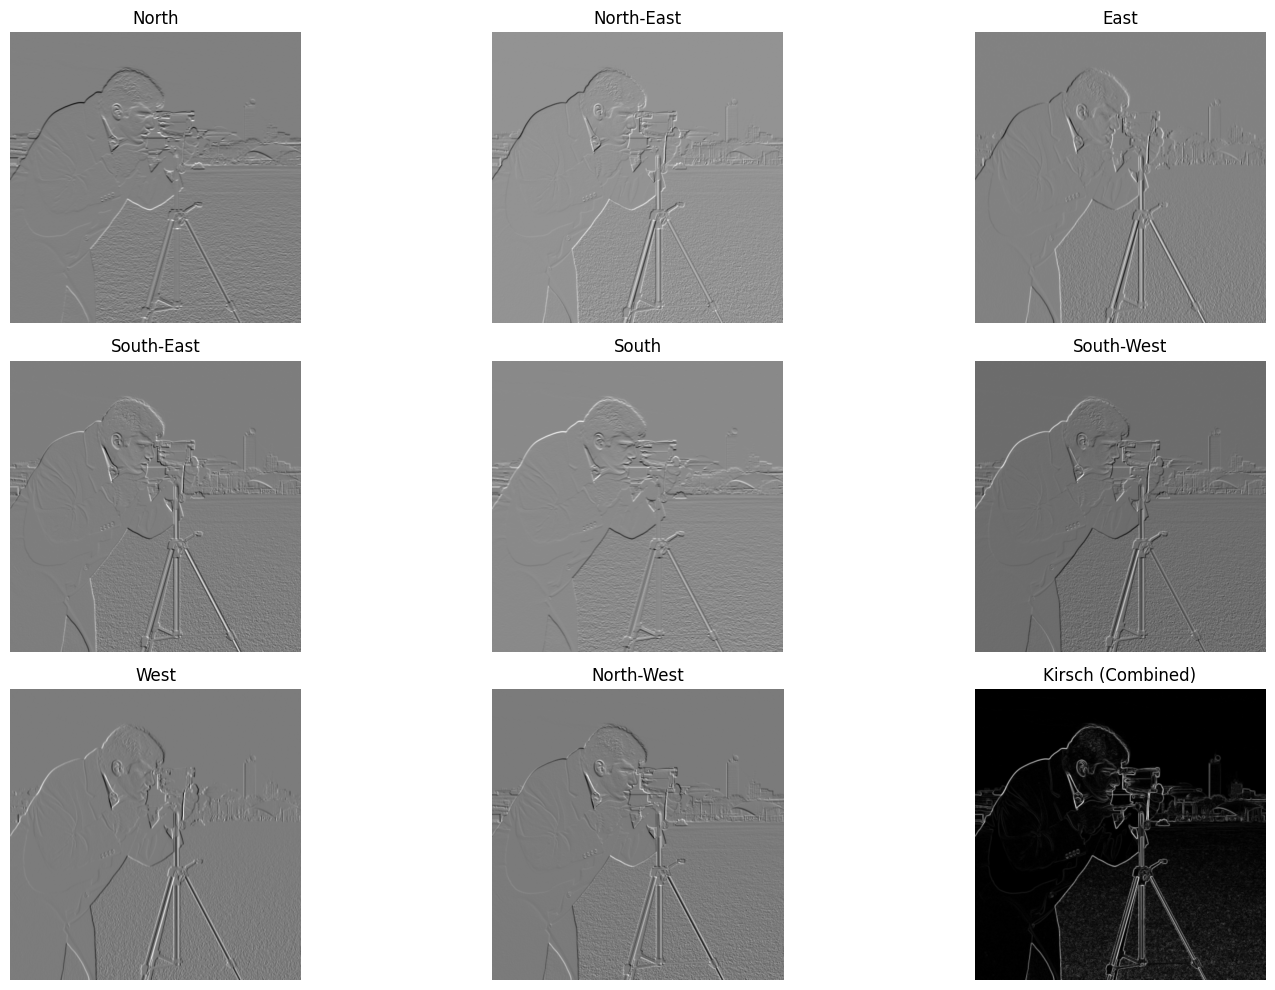

In [46]:
plt.figure(figsize=(16, 10))
for i, (name, response) in enumerate(responses):
    plt.subplot(3, 3, i+1)
    plt.title(name)
    plt.imshow(response, cmap='gray')
    plt.axis('off')

plt.subplot(3, 3, 9)
plt.title("Kirsch (Combined)")
plt.imshow(kirsch_final, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()